# Forecasting con Chronos-2 — M5 Forecasting Accuracy (holdout de 28 días)

Este notebook adapta la misma filosofía del notebook de tráfico urbano a **M5 Forecasting Accuracy** usando los CSVs ya preprocesados:

- `dataset/processed/m5_context.csv`
- `dataset/processed/m5_future.csv`
- `dataset/processed/m5_actuals.csv`

## Objetivo
Predecir las **ventas unitarias diarias** (`target`) de cada serie `item-store` con **Chronos-2**, utilizando covariables futuras conocidas:

- `sell_price`
- `snap`
- `wday`
- `month`
- `event_any`
- `event_type_main`

## Esquema de evaluación
- **`m5_context.csv`**: histórico observado que entra al modelo.
- **`m5_future.csv`**: covariables del horizonte futuro de 28 días, **sin target**.
- **`m5_actuals.csv`**: verdad real del horizonte, usada **solo** para validar.

> Nota: el benchmark oficial de M5 usa **WRMSSE**. En este notebook calculamos métricas más directas y comparables con tu flujo actual: **MAE, RMSE, sMAPE, WAPE, MASE y WQL**.


In [1]:
%pip install "chronos-forecasting>=2.0" pandas numpy torch matplotlib seaborn

import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from chronos import Chronos2Pipeline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_DIR = "dataset/processed"
CONTEXT_PATH = os.path.join(DATA_DIR, "m5_context.csv")
FUTURE_PATH = os.path.join(DATA_DIR, "m5_future.csv")
ACTUALS_PATH = os.path.join(DATA_DIR, "m5_actuals.csv")

# ---------------------------
# Configuración principal
# ---------------------------
PREDICTION_LENGTH = 28
MAX_SERIES = 500          # None -> usar todas las series (muy pesado). 500 es una buena primera corrida.
SERIES_SELECTION = "dense_random"   # options: "random", "dense_random", "top_total_sales"
HISTORY_DAYS = 1092       # None -> usar todo el histórico; prueba 365 si vas justo de RAM/tiempo
BATCH_SIZE = 64
QUANTILE_LEVELS = [0.1, 0.5, 0.9]
MASE_SEASONALITY = 7      # diario retail -> patrón semanal
VAL_LENGTH = 28
SEED = 42

np.random.seed(SEED)



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/Users/jai/development/git/unir/master-ia/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga de los CSVs procesados

Este notebook **no** reprocesa los ficheros crudos de Kaggle. Asume que ya has generado los tres CSVs finales desde tu notebook de preparación.


In [2]:
for path in [CONTEXT_PATH, FUTURE_PATH, ACTUALS_PATH]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"No existe: {path}")

context_df = pd.read_csv(CONTEXT_PATH, parse_dates=["timestamp"])
future_df = pd.read_csv(FUTURE_PATH, parse_dates=["timestamp"])
actuals_df = pd.read_csv(ACTUALS_PATH, parse_dates=["timestamp"])

print("CSV cargados correctamente:")
print(f"- context: {context_df.shape[0]:,} filas, {context_df.shape[1]} columnas")
print(f"- future : {future_df.shape[0]:,} filas, {future_df.shape[1]} columnas")
print(f"- actuals: {actuals_df.shape[0]:,} filas, {actuals_df.shape[1]} columnas")
print()

print(f"Series en context: {context_df['id'].nunique():,}")
print(f"Series en future : {future_df['id'].nunique():,}")
print(f"Series en actuals: {actuals_df['id'].nunique():,}")
print()

print(f"Rango histórico: {context_df['timestamp'].min()} → {context_df['timestamp'].max()}")
print(f"Rango holdout  : {future_df['timestamp'].min()} → {future_df['timestamp'].max()}")

display(context_df.head())


CSV cargados correctamente:
- context: 58,327,370 filas, 9 columnas
- future : 853,720 filas, 8 columnas
- actuals: 853,720 filas, 3 columnas

Series en context: 30,490
Series en future : 30,490
Series en actuals: 30,490

Rango histórico: 2011-01-29 00:00:00 → 2016-04-24 00:00:00
Rango holdout  : 2016-04-25 00:00:00 → 2016-05-22 00:00:00


,id,timestamp,target,sell_price,snap,wday,month,event_any,event_type_main
0,FOODS_1_001_CA_1,2011-01-29,3,2.0,0.0,1,1,0,NaN
1,FOODS_1_001_CA_1,2011-01-30,0,2.0,0.0,2,1,0,NaN
2,FOODS_1_001_CA_1,2011-01-31,0,2.0,0.0,3,1,0,NaN
3,FOODS_1_001_CA_1,2011-02-01,1,2.0,1.0,4,2,0,NaN
4,FOODS_1_001_CA_1,2011-02-02,4,2.0,1.0,5,2,0,NaN


In [3]:
import os
import pandas as pd
import numpy as np

# ============================================================
# SERIES SUBSET CONFIG
# ============================================================
RANDOM_SEED = 42

# For dense_random:
# keep only the densest X% of series, then sample randomly from them
DENSE_QUANTILE = 0.75   # 0.75 = top 25% densest series
DENSITY_METRIC = "nonzero_ratio"  # recommended for M5

# Save different subset files depending on the strategy
SELECTED_IDS_PATH = (
    f"dataset/processed/m5_selected_ids__{SERIES_SELECTION}"
    f"__n{MAX_SERIES}"
    f"__q{int(DENSE_QUANTILE*100)}"
    f"__seed{RANDOM_SEED}.csv"
)

# ============================================================
# BUILD SERIES-LEVEL STATS FROM FULL CONTEXT
# ============================================================
series_stats_full = (
    context_df.groupby("id")
    .agg(
        total_sales=("target", "sum"),
        mean_sales=("target", "mean"),
        median_sales=("target", "median"),
        nonzero_days=("target", lambda s: int((s > 0).sum())),
        n_days=("target", "size"),
    )
    .reset_index()
)

series_stats_full["nonzero_ratio"] = (
        series_stats_full["nonzero_days"] / series_stats_full["n_days"]
)

all_ids = series_stats_full["id"].drop_duplicates().sort_values().reset_index(drop=True)

# ============================================================
# CREATE OR LOAD FIXED SUBSET OF IDS
# ============================================================
if MAX_SERIES is None:
    selected_ids = all_ids.copy()
    print(f"MAX_SERIES=None -> using all {len(selected_ids)} series")

else:
    if os.path.exists(SELECTED_IDS_PATH):
        selected_ids = pd.read_csv(SELECTED_IDS_PATH)["id"].drop_duplicates().reset_index(drop=True)
        print(f"Loaded existing selected IDs from: {SELECTED_IDS_PATH}")
        print(f"Loaded {len(selected_ids)} series")

    else:
        if SERIES_SELECTION == "random":
            selected_ids = (
                all_ids.sample(n=MAX_SERIES, random_state=RANDOM_SEED)
                .sort_values()
                .reset_index(drop=True)
            )

        elif SERIES_SELECTION == "top_total_sales":
            selected_ids = (
                series_stats_full.sort_values("total_sales", ascending=False)
                .head(MAX_SERIES)["id"]
                .sort_values()
                .reset_index(drop=True)
            )

        elif SERIES_SELECTION == "dense_random":
            if DENSITY_METRIC not in series_stats_full.columns:
                raise ValueError(
                    f"DENSITY_METRIC='{DENSITY_METRIC}' not found. "
                    f"Available: {series_stats_full.columns.tolist()}"
                )

            density_threshold = series_stats_full[DENSITY_METRIC].quantile(DENSE_QUANTILE)

            dense_pool = series_stats_full[
                series_stats_full[DENSITY_METRIC] >= density_threshold
                ].copy()

            if len(dense_pool) < MAX_SERIES:
                raise ValueError(
                    f"Dense pool too small: only {len(dense_pool)} eligible series, "
                    f"but MAX_SERIES={MAX_SERIES}. "
                    f"Lower DENSE_QUANTILE or reduce MAX_SERIES."
                )

            selected_ids = (
                dense_pool["id"]
                .sample(n=MAX_SERIES, random_state=RANDOM_SEED)
                .sort_values()
                .reset_index(drop=True)
            )

            print(f"Dense sampling using metric='{DENSITY_METRIC}'")
            print(f"Density threshold at quantile {DENSE_QUANTILE:.2f}: {density_threshold:.6f}")
            print(f"Dense pool size: {len(dense_pool)}")

        else:
            raise ValueError("SERIES_SELECTION must be 'random', 'dense_random', or 'top_total_sales'")

        pd.DataFrame({"id": selected_ids}).to_csv(SELECTED_IDS_PATH, index=False)
        print(f"Created and saved selected IDs to: {SELECTED_IDS_PATH}")
        print(f"Saved {len(selected_ids)} series using selection='{SERIES_SELECTION}'")

# ============================================================
# FILTER ALL DATAFRAMES WITH THE SAME IDS
# ============================================================
selected_ids_set = set(selected_ids)

context_df = context_df[context_df["id"].isin(selected_ids_set)].copy()
future_df  = future_df[future_df["id"].isin(selected_ids_set)].copy()
actuals_df = actuals_df[actuals_df["id"].isin(selected_ids_set)].copy()

# Deterministic order
context_df = context_df.sort_values(["id", "timestamp"]).reset_index(drop=True)
future_df  = future_df.sort_values(["id", "timestamp"]).reset_index(drop=True)
actuals_df = actuals_df.sort_values(["id", "timestamp"]).reset_index(drop=True)

# ============================================================
# REPORT THE SELECTED SUBSET
# ============================================================
selected_stats = (
    series_stats_full[series_stats_full["id"].isin(selected_ids_set)]
    .sort_values([DENSITY_METRIC if DENSITY_METRIC in series_stats_full.columns else "total_sales"], ascending=False)
    .reset_index(drop=True)
)

print("\nFiltered shapes:")
print("context_df:", context_df.shape)
print("future_df :", future_df.shape)
print("actuals_df:", actuals_df.shape)

print("\nUnique series after filtering:")
print("context_df:", context_df["id"].nunique())
print("future_df :", future_df["id"].nunique())
print("actuals_df:", actuals_df["id"].nunique())

print("\nSelected subset summary:")
display(
    selected_stats[["id", "nonzero_days", "n_days", "nonzero_ratio", "mean_sales", "total_sales"]]
    .head(10)
)

print("\nDense subset descriptive stats:")
display(
    selected_stats[["nonzero_ratio", "mean_sales", "total_sales"]]
    .describe()
)

Loaded existing selected IDs from: dataset/processed/m5_selected_ids__dense_random__n500__q75__seed42.csv
Loaded 500 series

Filtered shapes:
context_df: (956500, 9)
future_df : (14000, 8)
actuals_df: (14000, 3)

Unique series after filtering:
context_df: 500
future_df : 500
actuals_df: 500

Selected subset summary:


,id,nonzero_days,n_days,nonzero_ratio,mean_sales,total_sales
0,FOODS_3_555_CA_2,1906,1913,0.996341,16.205436,31001
1,FOODS_3_080_WI_1,1906,1913,0.996341,12.945635,24765
2,FOODS_3_694_WI_3,1906,1913,0.996341,44.763722,85633
3,FOODS_3_714_CA_3,1905,1913,0.995818,27.126503,51893
4,FOODS_3_694_WI_1,1904,1913,0.995295,21.551490,41228
5,FOODS_3_668_WI_2,1893,1913,0.989545,7.618923,14575
6,FOODS_3_714_CA_2,1890,1913,0.987977,10.853110,20762
7,FOODS_3_473_TX_3,1882,1913,0.983795,5.991636,11462
8,FOODS_3_228_TX_1,1874,1913,0.979613,6.920544,13239
9,FOODS_1_018_CA_1,1860,1913,0.972295,9.706221,18568



Dense subset descriptive stats:


,nonzero_ratio,mean_sales,total_sales
count,500.000000,500.000000,500.000000
mean,0.647129,3.295940,6305.134000
std,0.136041,4.114742,7871.501574
min,0.463147,0.709357,1357.000000
25%,0.533717,1.273001,2435.250000
50%,0.625719,1.944328,3719.500000
75%,0.731312,3.619707,6924.500000
max,0.996341,44.763722,85633.000000


## 2. Definición de target y covariables para Chronos-2

En este problema:

- **Target**: `target` = ventas unitarias diarias de cada serie `id`
- **ID**: `id` = combinación `item_id + "_" + store_id`
- **Timestamp**: `timestamp`

### Covariables futuras conocidas
Todas las covariables del notebook se tratan como **future covariates**, porque están disponibles para el horizonte futuro de 28 días:

- `sell_price`: precio de venta conocido en la semana comercial
- `snap`: indicador SNAP del estado de la serie
- `wday`: día de la semana
- `month`: mes
- `event_any`: binaria, hay evento/no hay evento
- `event_type_main`: tipo principal de evento


In [4]:
TARGET = "target"
ID_COL = "id"
TS_COL = "timestamp"

PAST_ONLY_COVARIATES = []
FUTURE_COVARIATES = [
    "sell_price",
    "snap",
    "wday",
    "month",
    "event_any",
    "event_type_main",
]
CATEGORICAL_AS_STRING = ["snap", "wday", "month", "event_any", "event_type_main"]

def prepare_panel(df, has_target=True):
    df = df.copy()
    df[TS_COL] = pd.to_datetime(df[TS_COL])

    if has_target:
        df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce").fillna(0.0).astype(float)

    if "sell_price" in df.columns:
        df["sell_price"] = pd.to_numeric(df["sell_price"], errors="coerce")

    for col in ["snap", "wday", "month", "event_any"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

    if "event_type_main" in df.columns:
        df["event_type_main"] = df["event_type_main"].fillna("None").astype(str)

    df = df.sort_values([ID_COL, TS_COL]).reset_index(drop=True)
    return df

context_df = prepare_panel(context_df, has_target=True)
future_df = prepare_panel(future_df, has_target=False)
actuals_df = prepare_panel(actuals_df, has_target=True)

# Relleno robusto de sell_price por serie
def fill_sell_price(context_df, future_df):
    context_df = context_df.copy()
    future_df = future_df.copy()

    context_df["sell_price"] = (
        context_df.groupby(ID_COL)["sell_price"]
        .transform(lambda s: s.ffill().bfill())
    )

    median_price_by_id = context_df.groupby(ID_COL)["sell_price"].median()

    future_df["sell_price"] = (
        future_df.groupby(ID_COL)["sell_price"]
        .transform(lambda s: s.ffill().bfill())
    )
    future_df["sell_price"] = future_df["sell_price"].fillna(future_df[ID_COL].map(median_price_by_id))

    global_median = context_df["sell_price"].median()
    context_df["sell_price"] = context_df["sell_price"].fillna(global_median)
    future_df["sell_price"] = future_df["sell_price"].fillna(global_median)

    return context_df, future_df

context_df, future_df = fill_sell_price(context_df, future_df)

# Convertir covariables categóricas a string en ambos paneles
for col in CATEGORICAL_AS_STRING:
    if col in context_df.columns:
        context_df[col] = context_df[col].astype(str)
    if col in future_df.columns:
        future_df[col] = future_df[col].astype(str)

print("Paneles preparados.")
print("Columnas de context:", context_df.columns.tolist())
print("Columnas de future :", future_df.columns.tolist())
print("Columnas de actuals:", actuals_df.columns.tolist())


Paneles preparados.
Columnas de context: ['id', 'timestamp', 'target', 'sell_price', 'snap', 'wday', 'month', 'event_any', 'event_type_main']
Columnas de future : ['id', 'timestamp', 'sell_price', 'snap', 'wday', 'month', 'event_any', 'event_type_main']
Columnas de actuals: ['id', 'timestamp', 'target']


## 3. Selección opcional de series y comprobaciones de integridad

M5 completo tiene **30.490 series base**, por lo que una ejecución completa puede ser muy pesada.
Por eso el notebook permite trabajar con un subconjunto, por ejemplo las series con mayor venta total.

Este notebook usa `HISTORY_DAYS = 1092` (~3 años de contexto). Puedes cambiar:

- `MAX_SERIES = 500` para una primera corrida razonable
- `MAX_SERIES = None` para usar todas las series
- `HISTORY_DAYS = 728` si quieres reducir el contexto a ~2 años (más rápido)

In [5]:
series_stats = (
    context_df.groupby(ID_COL)
    .agg(
        total_sales=(TARGET, "sum"),
        mean_sales=(TARGET, "mean"),
        median_sales=(TARGET, "median"),
        nonzero_days=(TARGET, lambda s: int((s > 0).sum())),
        n_days=(TARGET, "size"),
    )
    .reset_index()
)

# Contexto que usaremos para inferencia (posiblemente truncado)
if HISTORY_DAYS is None:
    context_model_df = context_df.copy()
else:
    context_model_df = (
        context_df.sort_values([ID_COL, TS_COL])
        .groupby(ID_COL, group_keys=False)
        .tail(HISTORY_DAYS)
        .copy()
    )

expected_context_days = HISTORY_DAYS if HISTORY_DAYS is not None else context_df.groupby(ID_COL).size().max()

context_counts = context_model_df.groupby(ID_COL).size()

print("Contexto usado por Chronos-2:")
print(f"  HISTORY_DAYS configurado: {HISTORY_DAYS}")
print(f"  filas context_model_df: {len(context_model_df):,}")
print(f"  series: {context_model_df[ID_COL].nunique():,}")
print(f"  días por serie (min/med/max): {context_counts.min()} / {int(context_counts.median())} / {context_counts.max()}")

assert context_counts.nunique() == 1, "No todas las series tienen la misma longitud de contexto."
if HISTORY_DAYS is not None:
    assert context_counts.iloc[0] == HISTORY_DAYS, "El contexto no coincide con HISTORY_DAYS."

# ---------------------------
# Sanity checks
# ---------------------------
assert context_df[ID_COL].nunique() == future_df[ID_COL].nunique() == actuals_df[ID_COL].nunique(), (
    "Número distinto de series entre context/future/actuals."
)

future_counts = future_df.groupby(ID_COL).size()
actuals_counts = actuals_df.groupby(ID_COL).size()

assert future_counts.eq(PREDICTION_LENGTH).all(), "Alguna serie en future no tiene exactamente 28 filas."
assert actuals_counts.eq(PREDICTION_LENGTH).all(), "Alguna serie en actuals no tiene exactamente 28 filas."

future_keys = (
    future_df[[ID_COL, TS_COL]]
    .drop_duplicates()
    .sort_values([ID_COL, TS_COL])
    .reset_index(drop=True)
)
actuals_keys = (
    actuals_df[[ID_COL, TS_COL]]
    .drop_duplicates()
    .sort_values([ID_COL, TS_COL])
    .reset_index(drop=True)
)

assert future_keys.equals(actuals_keys), "future y actuals no tienen exactamente las mismas claves (id, timestamp)."

context_counts = context_model_df.groupby(ID_COL).size()
assert context_counts.min() > MASE_SEASONALITY, "Alguna serie tiene demasiado poco histórico para MASE."

print(f"Series ya filtradas: {context_df[ID_COL].nunique():,}")
print(f"Filas context completas   : {len(context_df):,}")
print(f"Filas context para modelo : {len(context_model_df):,}")
print(f"Filas future             : {len(future_df):,}")
print(f"Filas actuals            : {len(actuals_df):,}")
print()
print(f"Histórico por serie (min/med/max): {context_counts.min()} / {int(context_counts.median())} / {context_counts.max()}")
print(f"Rango del holdout: {future_df[TS_COL].min()} → {future_df[TS_COL].max()}")

display(series_stats.sort_values("total_sales", ascending=False).head(10))

Contexto usado por Chronos-2:
  HISTORY_DAYS configurado: 1092
  filas context_model_df: 546,000
  series: 500
  días por serie (min/med/max): 1092 / 1092 / 1092
Series ya filtradas: 500
Filas context completas   : 956,500
Filas context para modelo : 546,000
Filas future             : 14,000
Filas actuals            : 14,000

Histórico por serie (min/med/max): 1092 / 1092 / 1092
Rango del holdout: 2016-04-25 00:00:00 → 2016-05-22 00:00:00


,id,total_sales,mean_sales,median_sales,nonzero_days,n_days
287,FOODS_3_694_WI_3,85633.0,44.763722,44.0,1906,1913
248,FOODS_3_541_CA_3,80491.0,42.075797,36.0,1656,1913
293,FOODS_3_714_CA_3,51893.0,27.126503,26.0,1905,1913
286,FOODS_3_694_WI_1,41228.0,21.551490,21.0,1904,1913
100,FOODS_2_360_CA_3,39659.0,20.731312,17.0,1540,1913
267,FOODS_3_607_TX_2,35561.0,18.589127,14.0,1302,1913
93,FOODS_2_326_WI_2,32796.0,17.143753,13.0,1241,1913
295,FOODS_3_723_TX_1,31907.0,16.679038,16.0,1443,1913
252,FOODS_3_555_CA_2,31001.0,16.205436,15.0,1906,1913
471,HOUSEHOLD_1_521_CA_3,30266.0,15.821223,14.0,1746,1913


## 4. Carga del modelo Chronos-2

Se intenta usar el mejor dispositivo disponible:

- CUDA si existe
- MPS en Apple Silicon
- CPU en último caso


In [6]:
def detect_device_and_dtype():
    if torch.cuda.is_available():
        return "cuda", torch.bfloat16
    mps_available = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    if mps_available:
        return "mps", torch.bfloat16
    return "cpu", torch.float32

DEVICE_MAP, DTYPE = detect_device_and_dtype()

print(f"Dispositivo seleccionado: {DEVICE_MAP}")
print(f"dtype seleccionado      : {DTYPE}")

pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    dtype=DTYPE,
    device_map=DEVICE_MAP,
)

print(f"Model loaded on device: {pipeline.model.device}")
print(f"Context length       : {pipeline.model_context_length}")
print(f"Default pred length  : {pipeline.model_prediction_length}")
print(f"Quantiles            : {pipeline.quantiles}")


Dispositivo seleccionado: mps
dtype seleccionado      : torch.bfloat16
Model loaded on device: mps:0
Context length       : 8192
Default pred length  : 1024
Quantiles            : [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]


## 5. Predicción del holdout de 28 días

Aquí usamos:

- `context_model_df` como histórico
- `future_df` como covariables conocidas del horizonte
- `predict_df(...)` para generar las predicciones multiserie


In [7]:
%%time

model_input_df = context_model_df[
    [ID_COL, TS_COL, TARGET] + PAST_ONLY_COVARIATES + FUTURE_COVARIATES
].copy()

model_future_df = future_df[
    [ID_COL, TS_COL] + FUTURE_COVARIATES
].copy()

forecast_df = pipeline.predict_df(
    df=model_input_df,
    future_df=model_future_df,
    id_column=ID_COL,
    timestamp_column=TS_COL,
    target=TARGET,
    prediction_length=PREDICTION_LENGTH,
    quantile_levels=QUANTILE_LEVELS,
    batch_size=BATCH_SIZE,
)

print(f"Forecast shape: {forecast_df.shape}")
display(forecast_df.head())


Forecast shape: (14000, 7)


,id,timestamp,target_name,predictions,0.1,0.5,0.9
0,FOODS_1_006_CA_2,2016-04-25,target,0.180664,0.032715,0.180664,2.875000
1,FOODS_1_006_CA_2,2016-04-26,target,0.222656,0.023926,0.222656,2.921875
2,FOODS_1_006_CA_2,2016-04-27,target,0.214844,0.023926,0.214844,2.984375
3,FOODS_1_006_CA_2,2016-04-28,target,0.273438,0.023926,0.273438,3.046875
4,FOODS_1_006_CA_2,2016-04-29,target,0.240234,0.015076,0.240234,3.062500


CPU times: user 3.35 s, sys: 308 ms, total: 3.66 s
Wall time: 20 s


## 6. Evaluación contra `m5_actuals.csv`

El paso importante es este:

1. **`future_df` no lleva target** porque representa lo que conoces antes de predecir.
2. **`actuals_df` sí lleva target** porque contiene la verdad real del holdout.
3. La validación se hace cruzando predicción y realidad por `(id, timestamp)`.

Además calculamos:

- **MAE**
- **RMSE**
- **sMAPE**
- **WAPE**
- **MASE** (con estacionalidad semanal `m=7`)
- **WQL** (si están disponibles las columnas de cuantiles)


In [8]:
# ------------------------------------------------------------
# Normalizar nombres de columnas de salida de Chronos-2
# ------------------------------------------------------------
forecast_df = forecast_df.copy()

prediction_candidates = ["predictions", "prediction", "median", "mean", "0.5"]
prediction_col = next((c for c in prediction_candidates if c in forecast_df.columns), None)

if prediction_col is None:
    raise KeyError(
        f"No encuentro una columna de predicción central en forecast_df. "
        f"Columnas disponibles: {forecast_df.columns.tolist()}"
    )

forecast_df["predictions"] = forecast_df[prediction_col]

quantile_col_map = {}
for q in QUANTILE_LEVELS:
    candidates = [
        str(q),
        f"q_{q}",
        f"quantile_{q}",
        f"p{int(q * 100)}",
    ]
    if q == 0.5:
        candidates = [prediction_col] + candidates

    found = next((c for c in candidates if c in forecast_df.columns), None)
    if found is not None:
        quantile_col_map[q] = found

print("Columna central de predicción:", prediction_col)
print("Mapa de columnas de cuantiles:", quantile_col_map)

# ------------------------------------------------------------
# Postprocesado de no negatividad para retail
# ------------------------------------------------------------
# La variable objetivo representa unidades vendidas, por lo que no admite
# valores negativos. Se aplica el mismo criterio a la predicción central
# y a los cuantiles disponibles antes del cálculo de métricas.

cols_to_clip = ["predictions"] + list(quantile_col_map.values())
cols_to_clip = list(dict.fromkeys([c for c in cols_to_clip if c in forecast_df.columns]))

negative_counts_before = {
    col: int((pd.to_numeric(forecast_df[col], errors="coerce") < 0).sum())
    for col in cols_to_clip
}

for col in cols_to_clip:
    forecast_df[col] = pd.to_numeric(forecast_df[col], errors="coerce").clip(lower=0.0)

negative_counts_after = {
    col: int((pd.to_numeric(forecast_df[col], errors="coerce") < 0).sum())
    for col in cols_to_clip
}

print("Clipping aplicado a columnas:", cols_to_clip)
print("Predicciones negativas antes del clipping:", negative_counts_before)
print("Predicciones negativas después del clipping:", negative_counts_after)

# ------------------------------------------------------------
# MASE denominators a partir del histórico únicamente
# ------------------------------------------------------------
def build_mase_denominators(df_hist, seasonality=7):
    denominators = {}
    for series_id, g in df_hist.groupby(ID_COL, sort=False):
        y = g.sort_values(TS_COL)[TARGET].to_numpy(dtype=np.float64)
        if len(y) <= seasonality:
            denominators[series_id] = np.nan
            continue

        diffs = np.abs(y[seasonality:] - y[:-seasonality])
        denom = diffs.mean() if len(diffs) > 0 else np.nan
        denominators[series_id] = denom if np.isfinite(denom) and denom > 0 else np.nan

    return pd.Series(denominators, name="mase_denom")

df_train_mase = (
    context_df.sort_values([ID_COL, TS_COL])
    .groupby(ID_COL, group_keys=False)
    .apply(lambda g: g.iloc[:-VAL_LENGTH])
    .reset_index(drop=True)
)

mase_denominators = build_mase_denominators(df_train_mase, seasonality=MASE_SEASONALITY)

print("MASE denominators construidos:")
print(f"  series: {len(mase_denominators):,}")
print(f"  válidos: {mase_denominators.notna().sum():,}")
print(f"  inválidos: {mase_denominators.isna().sum():,}")

# ------------------------------------------------------------
# Métricas
# ------------------------------------------------------------
def compute_metrics(group):
    actual = group[TARGET].to_numpy(dtype=np.float64)
    pred = group["predictions"].to_numpy(dtype=np.float64)
    abs_errors = np.abs(actual - pred)
    sq_errors = (actual - pred) ** 2

    mae = abs_errors.mean()
    rmse = np.sqrt(sq_errors.mean())

    denom_smape = np.abs(actual) + np.abs(pred)
    smape = np.mean(np.where(denom_smape > 0, 200.0 * abs_errors / denom_smape, 0.0))

    actual_sum = np.abs(actual).sum()
    wape = abs_errors.sum() / actual_sum if actual_sum > 0 else np.nan

    sensor_denoms = group[ID_COL].map(mase_denominators).to_numpy(dtype=np.float64)
    valid_scale = np.isfinite(sensor_denoms) & (sensor_denoms > 0)
    mase = np.mean(abs_errors[valid_scale] / sensor_denoms[valid_scale]) if valid_scale.any() else np.nan

    # Weighted Quantile Loss normalizada
    available_q = [q for q in QUANTILE_LEVELS if q in quantile_col_map]
    if len(available_q) > 0:
        wql_sum = 0.0
        for q in available_q:
            col = quantile_col_map[q]
            q_pred = group[col].to_numpy(dtype=np.float64)
            diff = actual - q_pred
            wql_sum += np.mean(np.where(diff >= 0, q * diff, (q - 1) * diff))

        mean_abs_actual = np.mean(np.abs(actual))
        wql = 2.0 * wql_sum / (len(available_q) * mean_abs_actual) if mean_abs_actual > 0 else np.nan
    else:
        wql = np.nan

    return pd.Series({
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE": smape,
        "WAPE": wape,
        "MASE": mase,
        "WQL": wql,
    })

# ------------------------------------------------------------
# Merge predicción vs realidad
# ------------------------------------------------------------
eval_df = actuals_df.merge(
    forecast_df,
    on=[ID_COL, TS_COL],
    how="inner",
)

assert len(eval_df) == len(actuals_df), (
    f"Tras el merge faltan filas. actuals={len(actuals_df):,} vs eval={len(eval_df):,}"
)

global_metrics = compute_metrics(eval_df).to_frame(name="Value")
print(f"Filas evaluadas: {len(eval_df):,}")
display(global_metrics.round(4))
display(eval_df.head())

Columna central de predicción: predictions
Mapa de columnas de cuantiles: {0.1: '0.1', 0.5: 'predictions', 0.9: '0.9'}
Clipping aplicado a columnas: ['predictions', '0.1', '0.9']
Predicciones negativas antes del clipping: {'predictions': 97, '0.1': 2568, '0.9': 0}
Predicciones negativas después del clipping: {'predictions': 0, '0.1': 0, '0.9': 0}
MASE denominators construidos:
  series: 500
  válidos: 500
  inválidos: 0
Filas evaluadas: 14,000


/var/folders/jp/g9h79w4s2kvbjnyv8klyykqw0000gn/T/ipykernel_69407/555111988.py:82: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.iloc[:-VAL_LENGTH])
/var/folders/jp/g9h79w4s2kvbjnyv8klyykqw0000gn/T/ipykernel_69407/555111988.py:106: RuntimeWarning: invalid value encountered in divide
  smape = np.mean(np.where(denom_smape > 0, 200.0 * abs_errors / denom_smape, 0.0))


,Value
MAE,1.9481
RMSE,3.4510
sMAPE,98.1490
WAPE,0.5504
MASE,0.8333
WQL,0.3552


,id,timestamp,target,target_name,predictions,0.1,0.5,0.9
0,FOODS_1_006_CA_2,2016-04-25,0.0,target,0.180664,0.032715,0.180664,2.875000
1,FOODS_1_006_CA_2,2016-04-26,0.0,target,0.222656,0.023926,0.222656,2.921875
2,FOODS_1_006_CA_2,2016-04-27,0.0,target,0.214844,0.023926,0.214844,2.984375
3,FOODS_1_006_CA_2,2016-04-28,0.0,target,0.273438,0.023926,0.273438,3.046875
4,FOODS_1_006_CA_2,2016-04-29,1.0,target,0.240234,0.015076,0.240234,3.062500


## 7. Métricas por serie

Igual que en el notebook de tráfico, además del resumen global calculamos el comportamiento de cada serie por separado.


In [9]:
sensor_metrics = (
    eval_df.groupby(ID_COL)
    .apply(compute_metrics)
    .reset_index()
)

sensor_metrics = sensor_metrics.merge(
    series_stats[[ID_COL, "total_sales", "mean_sales", "median_sales", "nonzero_days", "n_days"]],
    on=ID_COL,
    how="left",
)

print(f"Series evaluadas: {sensor_metrics.shape[0]:,}")
display(sensor_metrics[['MAE', 'RMSE', 'sMAPE', 'WAPE', 'MASE', 'WQL']].describe().round(4))
display(sensor_metrics.sort_values("MAE").head(10))
display(sensor_metrics.sort_values("MAE", ascending=False).head(10))


/var/folders/jp/g9h79w4s2kvbjnyv8klyykqw0000gn/T/ipykernel_69407/555111988.py:106: RuntimeWarning: invalid value encountered in divide
  smape = np.mean(np.where(denom_smape > 0, 200.0 * abs_errors / denom_smape, 0.0))
/var/folders/jp/g9h79w4s2kvbjnyv8klyykqw0000gn/T/ipykernel_69407/555111988.py:106: RuntimeWarning: invalid value encountered in divide
  smape = np.mean(np.where(denom_smape > 0, 200.0 * abs_errors / denom_smape, 0.0))
/var/folders/jp/g9h79w4s2kvbjnyv8klyykqw0000gn/T/ipykernel_69407/555111988.py:106: RuntimeWarning: invalid value encountered in divide
  smape = np.mean(np.where(denom_smape > 0, 200.0 * abs_errors / denom_smape, 0.0))
/var/folders/jp/g9h79w4s2kvbjnyv8klyykqw0000gn/T/ipykernel_69407/555111988.py:106: RuntimeWarning: invalid value encountered in divide
  smape = np.mean(np.where(denom_smape > 0, 200.0 * abs_errors / denom_smape, 0.0))
/var/folders/jp/g9h79w4s2kvbjnyv8klyykqw0000gn/T/ipykernel_69407/555111988.py:106: RuntimeWarning: invalid value encountered

Series evaluadas: 500


,MAE,RMSE,sMAPE,WAPE,MASE,WQL
count,500.0000,500.0000,500.0000,496.0000,500.0000,496.0000
mean,1.9481,2.6047,98.1490,0.7376,0.8333,0.4721
std,1.6357,2.2661,45.6951,0.3196,0.3414,0.2333
min,0.0021,0.0036,16.3318,0.1610,0.0020,0.1066
25%,1.0191,1.3390,61.8627,0.5356,0.6208,0.3301
50%,1.4104,1.8448,87.4612,0.7036,0.7785,0.4330
75%,2.2058,2.8476,130.0836,0.9076,0.9774,0.5519
max,11.9955,20.3744,200.0000,3.5117,2.5026,2.2481


,id,MAE,RMSE,sMAPE,WAPE,MASE,WQL,total_sales,mean_sales,median_sales,nonzero_days,n_days
178,FOODS_3_276_CA_2,0.002060,0.003600,71.428571,NaN,0.002047,NaN,1741.0,0.910089,1.0,981,1913
476,HOUSEHOLD_1_541_TX_2,0.009319,0.010980,171.428571,NaN,0.006604,NaN,3104.0,1.622582,1.0,1168,1913
180,FOODS_3_276_WI_2,0.013550,0.013813,200.000000,NaN,0.013637,NaN,1815.0,0.948772,1.0,969,1913
179,FOODS_3_276_CA_3,0.068782,0.185082,199.462943,1.925903,0.045725,1.990055,3414.0,1.784631,1.0,1257,1913
264,FOODS_3_594_WI_1,0.092669,0.096155,200.000000,NaN,0.032481,NaN,6661.0,3.481965,1.0,977,1913
245,FOODS_3_508_TX_1,0.170105,0.362165,197.442223,1.190735,0.093109,0.778178,3396.0,1.775222,1.0,1155,1913
21,FOODS_1_083_TX_1,0.174901,0.530495,199.721970,1.224304,0.111306,1.591022,2401.0,1.255097,0.0,908,1913
248,FOODS_3_541_CA_3,0.219029,0.764058,114.285714,1.533203,0.010362,1.422396,80491.0,42.075797,36.0,1656,1913
432,HOUSEHOLD_1_365_TX_2,0.254813,0.487418,168.910964,1.019252,0.298713,0.759542,1379.0,0.720857,0.0,928,1913
275,FOODS_3_655_TX_1,0.370731,0.915691,198.026530,1.038048,0.346385,0.800076,1824.0,0.953476,0.0,890,1913


,id,MAE,RMSE,sMAPE,WAPE,MASE,WQL,total_sales,mean_sales,median_sales,nonzero_days,n_days
93,FOODS_2_326_WI_2,11.995536,17.453781,41.773250,0.360381,1.113355,0.257070,32796.0,17.143753,13.0,1241,1913
122,FOODS_3_086_WI_3,11.790179,14.580193,38.961055,0.354592,1.625098,0.214369,24133.0,12.615264,8.0,1481,1913
187,FOODS_3_295_TX_1,11.378348,20.374439,67.282882,0.698671,2.166535,0.591450,14028.0,7.332985,6.0,1589,1913
45,FOODS_1_204_WI_2,9.796875,11.230185,69.005561,0.597631,1.148258,0.350864,23633.0,12.353894,8.0,1247,1913
12,FOODS_1_043_TX_1,9.249843,10.837462,194.902498,0.988533,1.850757,0.943395,13117.0,6.856769,5.0,1396,1913
426,HOUSEHOLD_1_334_CA_1,9.102679,9.943465,124.467687,2.359954,2.481107,1.616069,12840.0,6.711971,5.0,1366,1913
171,FOODS_3_234_TX_2,8.707589,10.815912,61.427290,0.538217,0.555709,0.321720,27457.0,14.352849,8.0,1262,1913
295,FOODS_3_723_TX_1,8.072887,10.096514,85.381498,0.525676,0.838173,0.277007,31907.0,16.679038,16.0,1443,1913
445,HOUSEHOLD_1_418_WI_2,7.352679,9.873531,38.555774,0.366979,1.126659,0.237892,17260.0,9.022478,7.0,1305,1913
414,HOUSEHOLD_1_254_CA_3,7.266741,9.297235,74.796216,0.607369,2.149124,0.387353,9807.0,5.126503,0.0,924,1913


## 8. Métricas por horizonte y visualizaciones globales

Aquí analizamos si el error empeora a medida que avanzamos en el horizonte 1..28.


In [10]:
horizon_eval = eval_df.copy()
forecast_start = eval_df[TS_COL].min()

horizon_eval["horizon"] = (
    (horizon_eval[TS_COL] - forecast_start).dt.days + 1
).astype(int)

horizon_eval["abs_error"] = np.abs(horizon_eval[TARGET] - horizon_eval["predictions"])
horizon_eval["sq_error"] = (horizon_eval[TARGET] - horizon_eval["predictions"]) ** 2
horizon_eval["smape_row"] = np.where(
    (np.abs(horizon_eval[TARGET]) + np.abs(horizon_eval["predictions"])) > 0,
    200.0 * horizon_eval["abs_error"] / (np.abs(horizon_eval[TARGET]) + np.abs(horizon_eval["predictions"])),
    0.0,
)
horizon_eval["mase_denom"] = horizon_eval[ID_COL].map(mase_denominators)
horizon_eval["scaled_abs_error"] = np.where(
    horizon_eval["mase_denom"].notna() & (horizon_eval["mase_denom"] > 0),
    horizon_eval["abs_error"] / horizon_eval["mase_denom"],
    np.nan,
)

horizon_metrics = (
    horizon_eval.groupby("horizon")
    .agg(
        MAE=("abs_error", "mean"),
        RMSE=("sq_error", lambda s: np.sqrt(np.mean(s))),
        sMAPE=("smape_row", "mean"),
        MASE=("scaled_abs_error", "mean"),
        n_rows=("abs_error", "size"),
    )
    .reset_index()
)

display(horizon_metrics.round(4))


,horizon,MAE,RMSE,sMAPE,MASE,n_rows
0,1,1.8490,4.2976,96.4451,0.7619,500
1,2,1.6411,2.5596,102.3707,0.7455,500
2,3,1.5424,2.8549,105.2679,0.6863,500
3,4,1.6682,3.4718,107.6123,0.6923,500
4,5,1.9285,3.0345,96.1829,0.8423,500
5,6,1.9588,3.2553,87.1291,0.8445,500
6,7,2.1529,3.8027,89.9128,0.8867,500
7,8,2.0163,3.6356,94.6064,0.8437,500
8,9,1.9066,3.1172,95.5471,0.8221,500
9,10,1.9779,3.7775,103.9479,0.7999,500


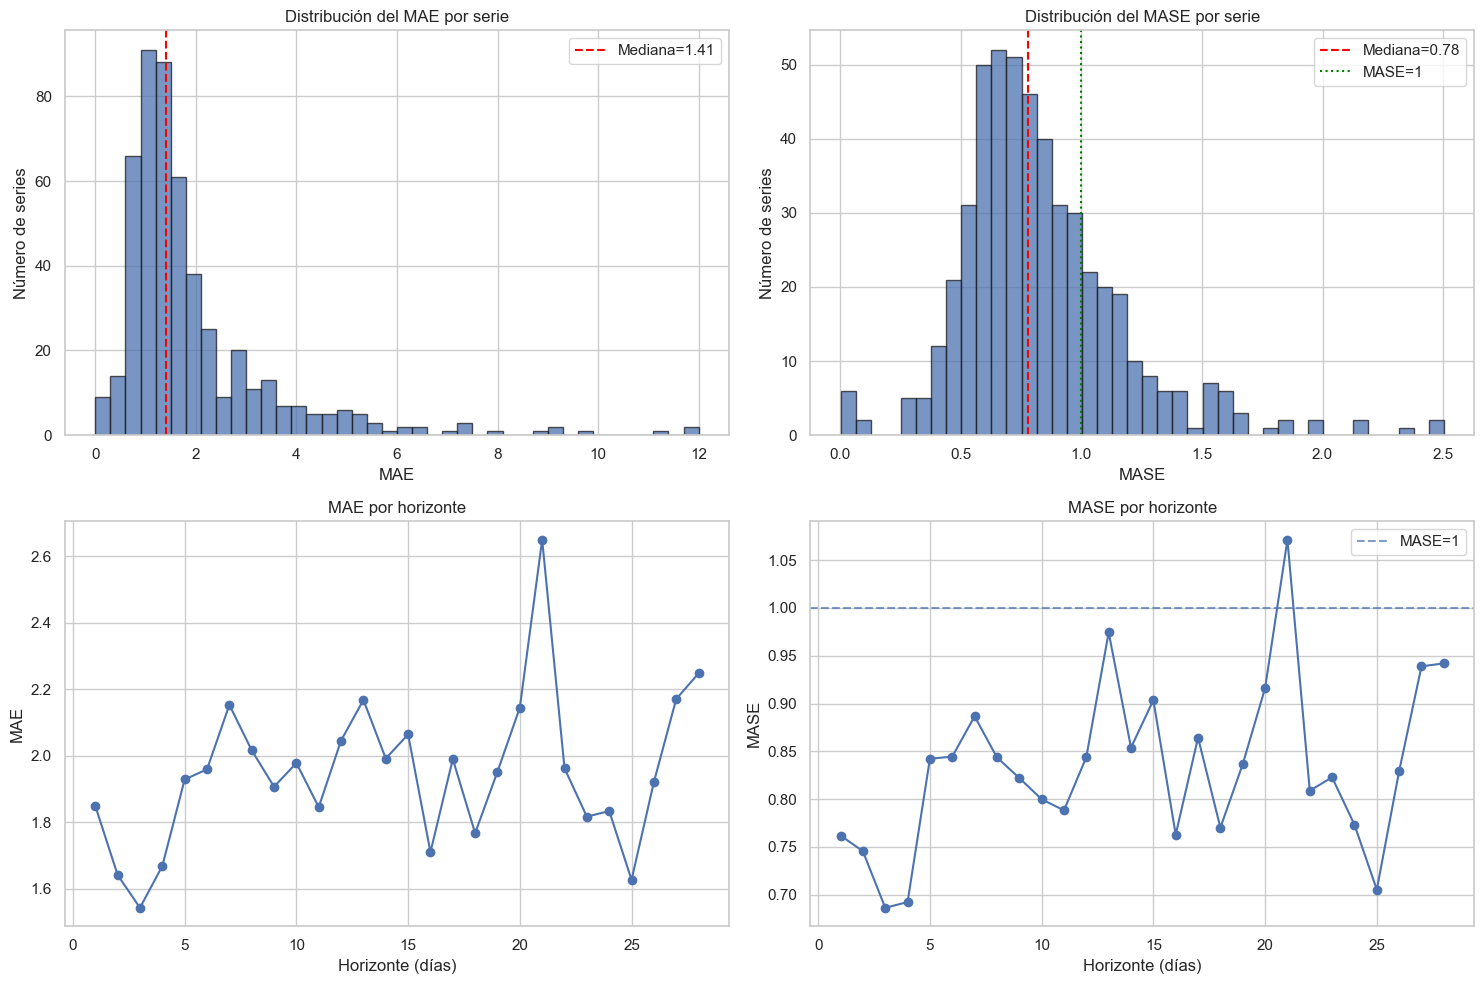

Series con MASE < 1 (mejor que naive semanal): 76.2%


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribución de MAE por serie
axes[0, 0].hist(sensor_metrics["MAE"], bins=40, edgecolor="k", alpha=0.75)
axes[0, 0].axvline(sensor_metrics["MAE"].median(), linestyle="--", color="red",
                   label=f"Mediana={sensor_metrics['MAE'].median():.2f}")
axes[0, 0].set_title("Distribución del MAE por serie")
axes[0, 0].set_xlabel("MAE")
axes[0, 0].set_ylabel("Número de series")
axes[0, 0].legend()

# Distribución de MASE por serie
valid_mase = sensor_metrics["MASE"].dropna()
axes[0, 1].hist(valid_mase, bins=40, edgecolor="k", alpha=0.75)
axes[0, 1].axvline(valid_mase.median(), linestyle="--", color="red",
                   label=f"Mediana={valid_mase.median():.2f}")
axes[0, 1].axvline(1.0, linestyle=":", color="green", label="MASE=1")
axes[0, 1].set_title("Distribución del MASE por serie")
axes[0, 1].set_xlabel("MASE")
axes[0, 1].set_ylabel("Número de series")
axes[0, 1].legend()

# MAE por horizonte
axes[1, 0].plot(horizon_metrics["horizon"], horizon_metrics["MAE"], marker="o")
axes[1, 0].set_title("MAE por horizonte")
axes[1, 0].set_xlabel("Horizonte (días)")
axes[1, 0].set_ylabel("MAE")

# MASE por horizonte
axes[1, 1].plot(horizon_metrics["horizon"], horizon_metrics["MASE"], marker="o")
axes[1, 1].axhline(1.0, linestyle="--", alpha=0.7, label="MASE=1")
axes[1, 1].set_title("MASE por horizonte")
axes[1, 1].set_xlabel("Horizonte (días)")
axes[1, 1].set_ylabel("MASE")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

pct_beats_naive = (valid_mase < 1.0).mean() * 100 if len(valid_mase) > 0 else np.nan
print(f"Series con MASE < 1 (mejor que naive semanal): {pct_beats_naive:.1f}%")


## 9. Visualización de algunas series representativas

Seleccionamos tres series activas para inspección visual:

- una de actividad baja
- una intermedia
- una alta


Series seleccionadas para gráfico:
  HOUSEHOLD_1_087_WI_3 | ventas acumuladas históricas=1871
  HOUSEHOLD_1_048_TX_2 | ventas acumuladas históricas=3726
  FOODS_1_173_CA_3 | ventas acumuladas históricas=13334


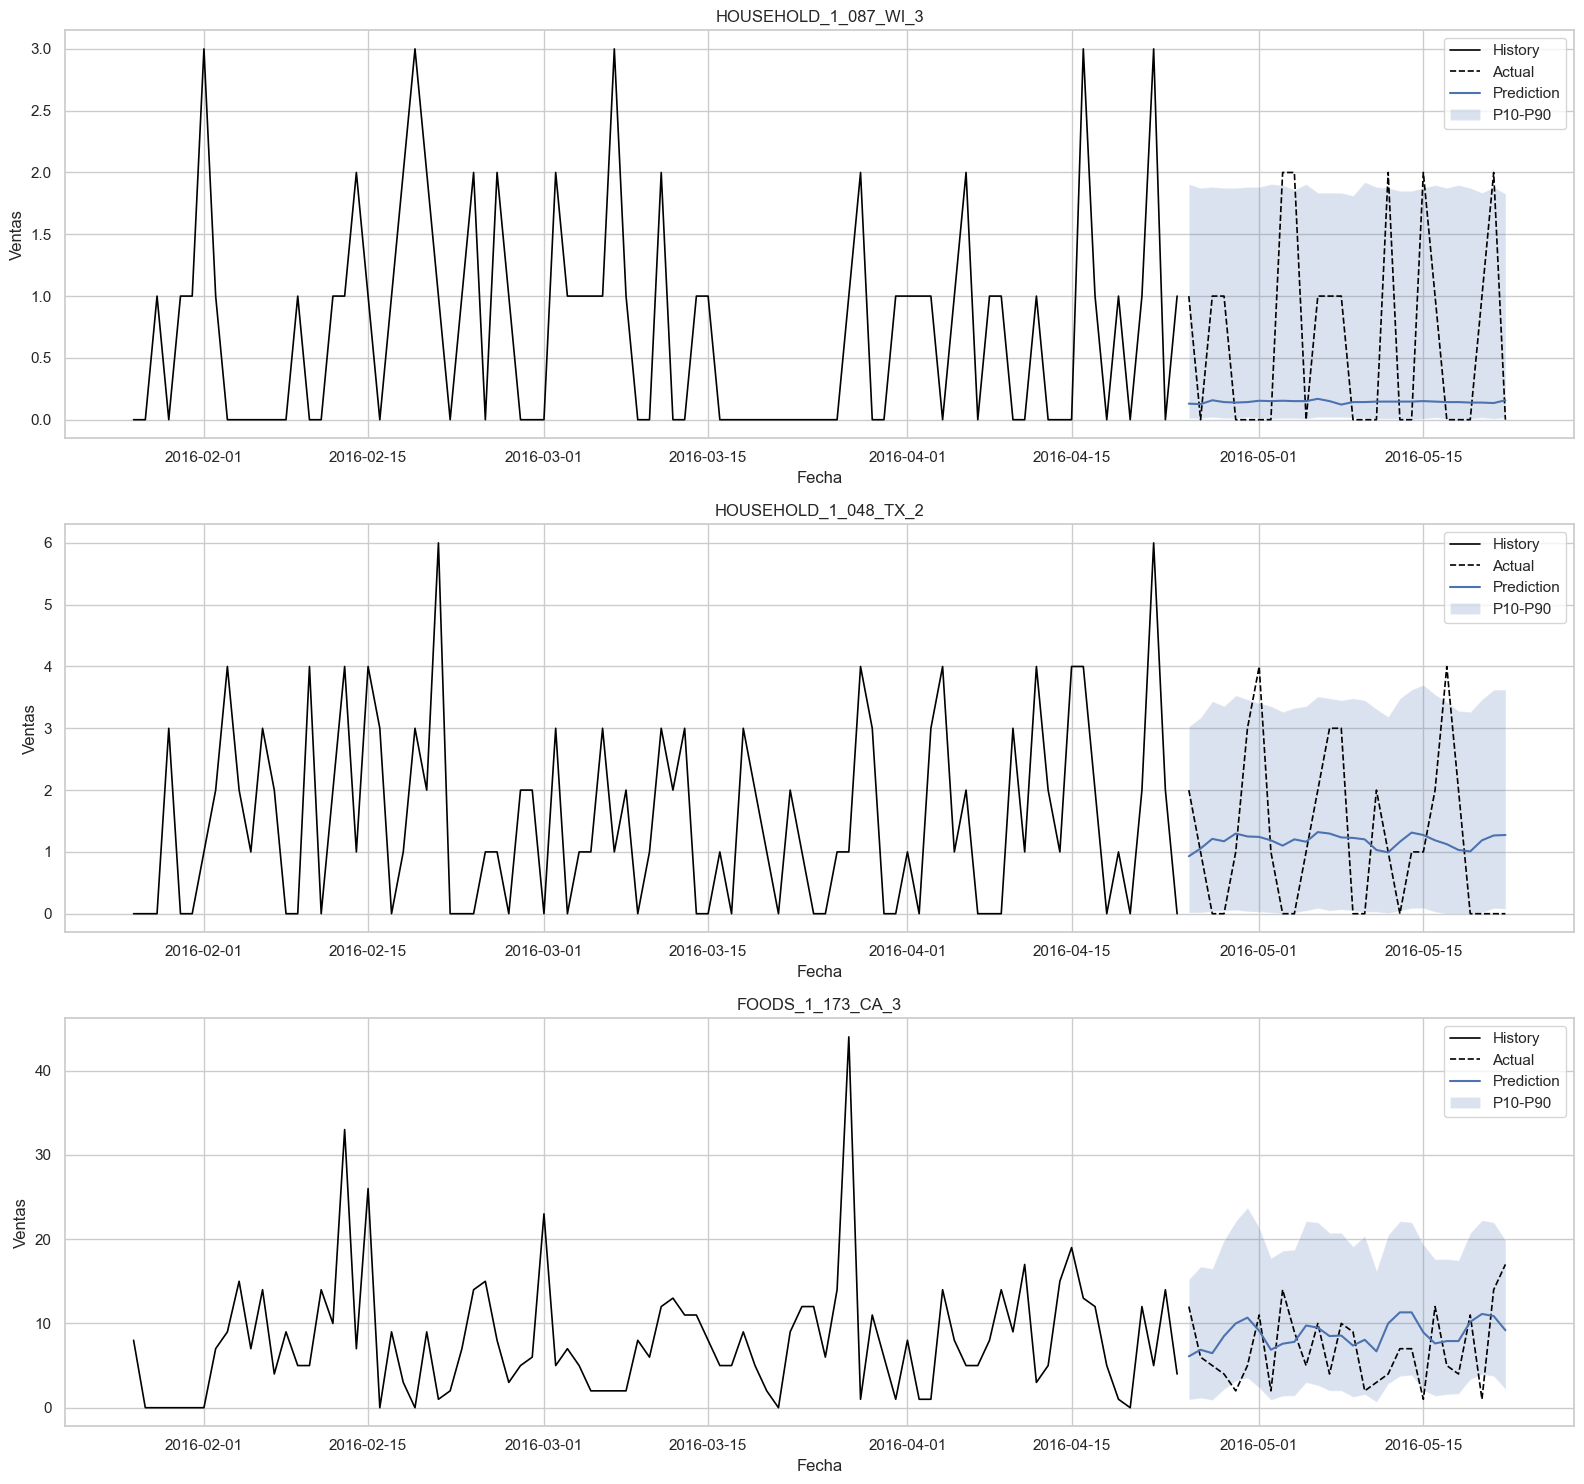

In [12]:
activity = (
    context_df.groupby(ID_COL)[TARGET]
    .sum()
    .sort_values()
)

active_ids = activity[activity > 0].index.tolist()
if len(active_ids) < 3:
    sample_ids = active_ids
else:
    sample_ids = [
        active_ids[len(active_ids) // 10],
        active_ids[len(active_ids) // 2],
        active_ids[9 * len(active_ids) // 10],
    ]

print("Series seleccionadas para gráfico:")
for sid in sample_ids:
    print(f"  {sid} | ventas acumuladas históricas={activity[sid]:.0f}")

history_plot_days = 90
q10_col = quantile_col_map.get(0.1)
q90_col = quantile_col_map.get(0.9)

fig, axes = plt.subplots(len(sample_ids), 1, figsize=(16, 5 * max(len(sample_ids), 1)), sharex=False)
if len(sample_ids) == 1:
    axes = [axes]

for ax, series_id in zip(axes, sample_ids):
    hist = (
        context_df[context_df[ID_COL] == series_id]
        .sort_values(TS_COL)
        .tail(history_plot_days)
    )
    pred = (
        eval_df[eval_df[ID_COL] == series_id]
        .sort_values(TS_COL)
    )

    ax.plot(hist[TS_COL], hist[TARGET], color="black", linewidth=1.2, label="History")
    ax.plot(pred[TS_COL], pred[TARGET], color="black", linestyle="--", linewidth=1.2, label="Actual")
    ax.plot(pred[TS_COL], pred["predictions"], linewidth=1.5, label="Prediction")

    if q10_col is not None and q90_col is not None:
        ax.fill_between(
            pred[TS_COL],
            pred[q10_col].astype(float),
            pred[q90_col].astype(float),
            alpha=0.2,
            label="P10-P90",
        )

    ax.set_title(series_id)
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Ventas")
    ax.legend()

plt.tight_layout()
plt.show()


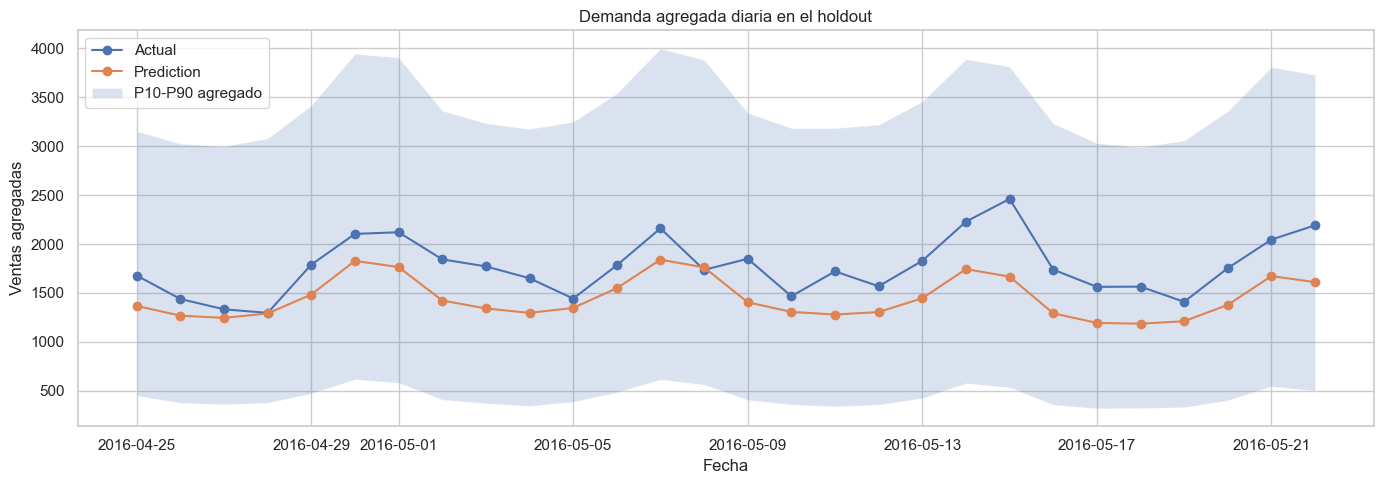

,timestamp,actual,prediction,p10,p90
0,2016-04-25,1678.0,1367.843506,450.530823,3155.148682
1,2016-04-26,1439.0,1268.135498,376.880646,3025.867432
2,2016-04-27,1333.0,1245.742188,363.427917,2999.299805
3,2016-04-28,1297.0,1290.756958,378.570923,3080.323242
4,2016-04-29,1790.0,1484.375244,472.640503,3418.668945


In [13]:
# Serie agregada: suma diaria de todas las series seleccionadas
daily_total = (
    eval_df.groupby(TS_COL)
    .agg(
        actual=(TARGET, "sum"),
        prediction=("predictions", "sum"),
    )
    .reset_index()
)

if q10_col is not None:
    daily_total["p10"] = eval_df.groupby(TS_COL)[q10_col].sum().values
if q90_col is not None:
    daily_total["p90"] = eval_df.groupby(TS_COL)[q90_col].sum().values

plt.figure(figsize=(14, 5))
plt.plot(daily_total[TS_COL], daily_total["actual"], marker="o", label="Actual")
plt.plot(daily_total[TS_COL], daily_total["prediction"], marker="o", label="Prediction")

if "p10" in daily_total.columns and "p90" in daily_total.columns:
    plt.fill_between(
        daily_total[TS_COL],
        daily_total["p10"],
        daily_total["p90"],
        alpha=0.2,
        label="P10-P90 agregado",
    )

plt.title("Demanda agregada diaria en el holdout")
plt.xlabel("Fecha")
plt.ylabel("Ventas agregadas")
plt.legend()
plt.tight_layout()
plt.show()

display(daily_total.head())


## 10. Guardado de resultados

Se guardan varios CSVs para reutilizarlos después en análisis, tablas del TFM o comparación con TimeXer.


In [14]:
OUTPUT_DIR = os.path.join(DATA_DIR, "chronos2_m5_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

forecast_path = os.path.join(OUTPUT_DIR, "m5_forecast_raw.csv")
eval_path = os.path.join(OUTPUT_DIR, "m5_eval_predictions_vs_actuals.csv")
sensor_metrics_path = os.path.join(OUTPUT_DIR, "m5_sensor_metrics.csv")
horizon_metrics_path = os.path.join(OUTPUT_DIR, "m5_horizon_metrics.csv")
global_metrics_path = os.path.join(OUTPUT_DIR, "m5_global_metrics.csv")

forecast_df.to_csv(forecast_path, index=False)
eval_df.to_csv(eval_path, index=False)
sensor_metrics.to_csv(sensor_metrics_path, index=False)
horizon_metrics.to_csv(horizon_metrics_path, index=False)
global_metrics.to_csv(global_metrics_path)

print("Ficheros guardados:")
print("-", forecast_path)
print("-", eval_path)
print("-", sensor_metrics_path)
print("-", horizon_metrics_path)
print("-", global_metrics_path)


Ficheros guardados:
- dataset/processed/chronos2_m5_outputs/m5_forecast_raw.csv
- dataset/processed/chronos2_m5_outputs/m5_eval_predictions_vs_actuals.csv
- dataset/processed/chronos2_m5_outputs/m5_sensor_metrics.csv
- dataset/processed/chronos2_m5_outputs/m5_horizon_metrics.csv
- dataset/processed/chronos2_m5_outputs/m5_global_metrics.csv


### Siguientes pasos naturales

1. Repetir la corrida con más series (`MAX_SERIES`) o con todas.
2. Añadir una baseline explícita (`naive_7`) para complementar MASE.
3. Implementar **WRMSSE** si quieres acercarte más al benchmark oficial de M5.
4. Replicar la misma lógica de evaluación en tu notebook de TimeXer para una comparación homogénea.


## 11. Conclusiones

### 11.1 Resumen del enfoque

Se ha implementado el modelo fundacional **Amazon Chronos-2** para forecasting de ventas unitarias en el dataset **M5 Forecasting Accuracy**, evaluando sobre un subconjunto de **500 series densas** seleccionadas aleatoriamente con filtro de calidad (percentil 75 de días no-cero, seed=42) del total de 30,490 series base. El horizonte de predicción es un **holdout único de 28 días** (2016-04-25 → 2016-05-22), usando los **últimos 1,092 días por serie** como contexto de entrada al modelo (aproximadamente 3 años). El modelo se ejecutó en Apple Silicon (MPS) con `bfloat16`.

### 11.2 Parámetros configurables

| Parámetro | Valor | Descripción |
|-----------|-------|-------------|
| `PREDICTION_LENGTH` | 28 días | Horizonte de predicción (holdout M5) |
| `HISTORY_DAYS` | 1,092 días | Contexto histórico usado por el modelo (~3 años) |
| `MAX_SERIES` | 500 | Series evaluadas del total de 30,490 |
| `SERIES_SELECTION` | `dense_random` | Filtro: selección aleatoria dentro del cuartil superior de nonzero_ratio — percentil 75, top 25 % de series más densas |
| `MASE_SEASONALITY` | 7 días | Estacionalidad semanal para la baseline naive |
| `SEED` | 42 | Reproducibilidad de la selección |

### 11.3 Rendimiento global

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| **MAE** | 1.948 uds/día | Error absoluto medio sobre 14,000 filas (500 series × 28 días) |
| **RMSE** | 3.451 uds/día | Penaliza errores grandes; ratio RMSE/MAE ≈ 1.77 |
| **sMAPE** | 98.1% | Elevado por series con valores muy bajos (efecto suelo) |
| **WAPE** | 0.550 | Error relativo agregado |
| **MASE** | 0.833 | < 1 indica superioridad sobre naive semanal (lag-7) |
| **WQL** | 0.355 | Calibración del intervalo cuantílico (P10–P90) |

El MASE global de **0.833** indica que Chronos-2 reduce el error del forecast ingenuo estacional en un **16.7%** en promedio. El WQL de 0.355 refleja la dificultad de calibrar intervalos de confianza en demanda intermitente.

### 11.4 Rendimiento por horizonte

Agregando los 28 días del holdout en cuatro bloques semanales:

| Bloque | MAE (uds/día) | MASE |
|--------|---------------|------|
| Semana 1 (días 1–7)   | 1.822 | 0.778 |
| Semana 2 (días 8–14)  | 1.993 | 0.849 |
| Semana 3 (días 15–21) | 2.042 | 0.878 |
| Semana 4 (días 22–28) | 1.940 | 0.831 |

El error es **mínimo en la primera semana** (MASE=0.778) y alcanza su pico en la tercera (MASE=0.878), con una ligera mejora en la cuarta. El único día con MASE > 1.0 es el **día 21** (MASE=1.071), coincidiendo con el tercer lunes del holdout, probablemente un patrón intra-semanal atípico. El mejor día es el **día 3** (MASE=0.686). La degradación entre la semana 1 y la 3 es moderada (+12.8%), sin colapso en el horizonte largo.

### 11.5 Rendimiento por serie

Distribución de métricas sobre las **500 series evaluadas**:

| Estadístico | MAE (uds/día) | MASE | WQL |
|-------------|---------------|------|-----|
| **P25**     | 1.019 | 0.621 | 0.330 |
| **Mediana** | 1.410 | 0.779 | 0.433 |
| **P75**     | 2.206 | 0.977 | 0.552 |
| **Media**   | 1.948 | 0.833 | 0.472 |
| **Máximo**  | 12.00 | 2.503 | 2.248 |

El **76.2% de las series** obtiene MASE < 1 (mejor que el forecast naive semanal). La mediana del MASE (0.779) es inferior a la media (0.833), lo que indica una distribución con sesgo positivo por series de demanda más irregular. Los peores resultados por MAE (p. ej., FOODS_2_326_WI_2 con MAE=12.00) corresponden a series de alta demanda pero con alta volatilidad intra-semanal.

### 11.6 Valoración global

**Fortalezas**:
1. **Zero-shot sobre dominio retail**: el modelo generaliza sin fine-tuning a series de ventas heterogéneas, superando al forecast naive en el **76.2%** de las series.
2. **Covariables futuras integradas**: se alimentan variables conocidas del horizonte (precio, SNAP, eventos, calendario), aprovechando la arquitectura encoder-decoder de Chronos-2.
3. **Inferencia ultrarrápida**: **20.0 s** para 500 series en MPS, sin necesidad de entrenamiento. Escalar a las 30,490 series requeriría ~20 minutos.
4. **Contexto de 1,092 días como ventana**: los ~3 años de historia por serie permiten capturar tres ciclos anuales completos, incluyendo variaciones interanuales de demanda y precios.

**Limitaciones**:
- **MASE = 0.833 y 76.2% de series con MASE < 1**: la demanda retail intermitente y estocástica es estructuralmente más difícil para modelos fundacionales que el tráfico rodado (donde Chronos-2 logra MASE ≈ 0.62 y 97% de sensores por encima del naive).
- **WQL alto (0.355)**: los intervalos de confianza están mal calibrados para series con muchos ceros y alta estocasticidad. Un post-procesamiento o fine-tuning mejoraría la cobertura probabilística.
- **sMAPE alto (98.1%)**: refleja la presencia de series con ventas muy bajas donde cualquier error absoluto produce porcentajes de error elevados; no es indicativo del error real de gestión.
- **Subconjunto de 500 series**: los resultados pueden no generalizar directamente al conjunto completo de 30,490 series, aunque la selección densa por q75 reduce el sesgo hacia las series más activas.
- **Evaluación single-shot (no rolling)**: a diferencia de los experimentos de tráfico, no se dispone de estimación de variabilidad temporal. La adición de una evaluación rolling revelaría la estabilidad del modelo ante cambios estacionales (p. ej., primavera vs. invierno).
- **Contexto truncado a 1,092 días**: se pierde el primer año de histórico (~2011–2013); el notebook con 1,456H muestra una leve mejora adicional en MASE.